# **This version can run one simulation and compare with baseline sucessfully. Only minor issue is with the vehicle count and cooldown. There is a place for improvement.**

# System Setup

## Imports and Installs

### Installs

In [54]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape

### Imports

In [55]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [56]:
import numpy as np
import pickle
import random
import json
from itertools import permutations
import time as time_module
import networkx as nx
from datetime import datetime
import geopy.distance
import heapq
import math
import heapq
import pickle
import os

## Parameters

In [57]:
state_name = "Ohio"
city_name = "Columbus"
mini = True

## Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [58]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


## Assign Data directory path

In [59]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"
output_dir = data_dir + "/UMST Graph/bundling"


In [60]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Output directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/bundling
Files in directory :  ['avg_hotspot_data.json', 'mygraph.json', 'mygraph.graphml', 'ExecutionTime_7_31.txt', 'Temp', 'Processed Location Data', 'Hotspot Data', 'Q Tables', 'Images', 'Original Location Data', 'gh_cache', 'Census Data', 'Deliveries', 'UMST Graph']



# Simulation Materials

#### Global Variables and Functions

In [61]:
INTERVALS = [900, 1200, 1500, 1800, 2700, 3600, 5400, 7200, 10800, 14400]   #?????

In [62]:
# Changed the directory
deliveries_dir = data_dir + f"/Deliveries"
try:
  os.mkdir(deliveries_dir)
except:
  print(deliveries_dir + " Already Exists")

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Deliveries Already Exists


### Deliveries

#### Delivery Class

In [63]:
# ============================================================
# 1. DELIVERY CLASS - Simplified
# ============================================================
class Delivery:
    """
    Represents a single delivery request.
    ONLY tracks its own state - no partner tracking.
    """
    id_counter = 0

    def __init__(self, start_node, end_node, start_time, time_tolerance_factor,
                 shortest_path=None):
        # Identity
        self.id = Delivery.id_counter
        Delivery.id_counter += 1

        # Route (immutable)
        self.start_node = start_node
        self.end_node = end_node
        self.shortest_path = shortest_path if shortest_path else [start_node, end_node]

        # Time constraints
        self.start_time = start_time
        self.TIME_TOLERANCE_FACTOR = time_tolerance_factor
        self.time_limit = None  # Set after initialization

        # Current state (mutable)
        self.current_node = start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0

        # Completion tracking
        self.completed = False
        self.successful = False
        self.end_time = None

        # Statistics
        self.distance_traveled = 0
        self.actual_path = [start_node]
        self.num_vehicle_changes = 0
        self.times_bundled = 0  # Track if delivery times bundle

        # Bundle reference (managed by Bundle class)
        self.current_bundle_id = None  # Just an ID reference, not the full object

    def get_next_node(self):
        """Get next node in planned path."""
        if self.path_index < len(self.shortest_path) - 1:
            return self.shortest_path[self.path_index + 1]
        return None

    def move_to_next_node(self, distance, travel_time):
        """Start transition to next node."""
        self.in_transition = True
        self.time_till_next_node = travel_time
        self.distance_traveled += distance

    def arrive_at_node(self, node):
        """Complete arrival at node."""
        self.in_transition = False
        self.current_node = node
        self.actual_path.append(node)
        self.path_index += 1

        # CRITICAL: Check if reached destination
        if self.current_node == self.end_node:
            self.completed = True
            # Note: successful status set later in finalize_results based on time_limit

    def reset(self):
        """Reset to initial state."""
        self.current_node = self.start_node
        self.path_index = 0
        self.in_transition = False
        self.time_till_next_node = 0
        self.wait_time_remaining = 0
        self.completed = False
        self.successful = False
        self.end_time = None
        self.distance_traveled = 0
        self.actual_path = [self.start_node]
        self.num_vehicle_changes = 0
        self.current_bundle_id = None

    def __repr__(self):
        status = "✅" if self.completed else ("🚗" if self.in_transition else "⏳")
        bundle = f"[B{self.current_bundle_id}]" if self.current_bundle_id else ""
        return f"D{self.id}:{self.start_node}→{self.end_node}|{status}{bundle}@N{self.current_node}"

#### Vehicle Class

In [64]:
# ============================================================
# 2. VEHICLE CLASS - Simple tracking
# ============================================================

class Vehicle:
    """
    Represents a physical vehicle.
    Can be reused for multiple trips (BUNDLING MODE ONLY).
    """
    id_counter = 0

    def __init__(self, start_node, allow_reuse=True):
        self.id = Vehicle.id_counter
        Vehicle.id_counter += 1

        self.current_node = start_node
        self.allow_reuse = allow_reuse  # Only true for bundling mode

        # Cumulative stats (never reset)
        self.total_distance = 0
        self.total_trips = 0
        self.all_deliveries_carried = set()

        # Current trip (reset on reuse)
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.is_in_use = False

        # Reuse management
        self.available_at_time = 0  # Time when vehicle becomes available
        self.cooldown_period = 600  # 10 minutes cooldown before reuse

    def move_to(self, next_node, distance):
        """Move vehicle to next node."""
        self.current_node = next_node
        self.total_distance += distance
        self.current_trip_distance += distance
        self.current_route.append(next_node)

    def start_new_trip(self, start_node, current_time):
        """Prepare for new trip (reuse)."""
        if not self.allow_reuse:
            raise ValueError("Vehicle reuse not allowed in baseline mode")

        self.current_node = start_node
        self.current_trip_distance = 0
        self.current_route = [start_node]
        self.total_trips += 1
        self.is_in_use = True
        self.available_at_time = 0  # Reset availability

    def release(self, current_time):
        """Mark as available for reuse after cooldown."""
        self.is_in_use = False
        if self.allow_reuse:
            self.available_at_time = current_time + self.cooldown_period

    def can_reuse(self, current_time):
        """Check if vehicle can be reused."""
        return self.allow_reuse and not self.is_in_use and current_time >= self.available_at_time

    def __repr__(self):
        return f"V{self.id}@N{self.current_node}|{self.total_distance/1000:.1f}km"

#### Delivery Bundle

In [65]:
# ============================================================
# 3. BUNDLE CLASS - Central bundling manager
# ============================================================

class Bundle:
    """
    Manages a group of deliveries sharing a vehicle.
    This is the SINGLE SOURCE OF TRUTH for bundling.
    """
    id_counter = 0

    def __init__(self, delivery_ids, vehicle, current_node, next_node, step):
        self.id = Bundle.id_counter
        Bundle.id_counter += 1

        self.delivery_ids = set(delivery_ids)  # Set of delivery IDs
        self.vehicle = vehicle
        self.current_node = current_node
        self.next_node = next_node
        self.created_at_step = step

        self.is_active = True
        self.dissolved_at_step = None
        self.dissolution_reason = None

    def add_delivery(self, delivery_id):
        """Add delivery to bundle."""
        self.delivery_ids.add(delivery_id)

    def remove_delivery(self, delivery_id):
        """Remove delivery from bundle."""
        self.delivery_ids.discard(delivery_id)

    def dissolve(self, step, reason):
        """Dissolve this bundle."""
        self.is_active = False
        self.dissolved_at_step = step
        self.dissolution_reason = reason

    def size(self):
        """Current bundle size."""
        return len(self.delivery_ids)

    def __repr__(self):
        status = "🟢" if self.is_active else "🔴"
        return f"{status}Bundle{self.id}:[{','.join(f'D{d}' for d in sorted(self.delivery_ids))}]@V{self.vehicle.id}"

#### DeliveryList Class

In [66]:
# ============================================================
# 4. DELIVERYLIST CLASS - Optimized with Pre-computed Paths
# ============================================================

class DeliveryList:
    """Manages collection of deliveries with shortest path calculation."""

    def __init__(self, max_delivery_time, load, time_tolerance_factor,
                 hours=1, peaks=[0.25, 0.75], sigma=10, num_hotspots=50,
                 adjacency_matrix=None, node_positions=None):

        self.load = load
        self.hours = hours
        self.peaks = peaks
        self.sigma = sigma
        self.time_tolerance_factor = time_tolerance_factor
        self.max_delivery_time = max_delivery_time  # e.g., 1800 for 30 mins
        self.num_hotspots = num_hotspots
        self.adjacency_matrix = adjacency_matrix
        self.node_positions = node_positions

        # Validate inputs
        if adjacency_matrix is None or node_positions is None:
            raise ValueError("adjacency_matrix and node_positions are required!")

        print("📊 Generating temporal distribution...")
        self.distribution, self.loads = self.generate_distribution()

        print("🗺️  Pre-computing all shortest paths...")
        self.precomputed_paths = {}  # (start, end) -> (travel_time, path)
        self.valid_pairs = []  # List of (start, end) pairs within time limit
        self.precompute_all_paths()

        print("📦 Generating deliveries with pre-computed paths...")
        self.deliveries = self.generate_deliveries()

        # Calculate time limits after generation
        print("⏱️  Calculating time limits...")
        self.calculate_time_limits()

        print(f"✅ Generated {len(self.deliveries)} deliveries")

    def generate_distribution(self):
        """Generate temporal distribution of deliveries."""
        mu_list = [peak * 60 * self.hours for peak in self.peaks]
        x = np.linspace(0, 60 * self.hours, 60 * self.hours)

        y_combined = np.zeros_like(x)
        for mu in mu_list:
            y_combined += (1 / (self.sigma * np.sqrt(2 * np.pi))) * \
                         np.exp(-0.5 * ((x - mu) / self.sigma) ** 2)

        loads = [int((self.load * (self.sigma * np.sqrt(2 * np.pi))) * y)
                for y in y_combined]

        return y_combined, loads

    def precompute_all_paths(self):
        """
        Pre-compute shortest paths for all node pairs.
        Stores both the travel time and path for quick lookup.
        Also creates a filtered list of valid pairs within max_delivery_time.
        """
        valid_nodes = list(range(self.num_hotspots))
        total_pairs = len(valid_nodes) * (len(valid_nodes) - 1)

        with tqdm(total=total_pairs, desc="Pre-computing paths") as pbar:
            for start in valid_nodes:
                for end in valid_nodes:
                    if start != end:
                        travel_time, path = astar_shortest_path(
                            adjacency=self.adjacency_matrix,
                            start=start,
                            goal=end,
                            node_positions=self.node_positions,
                            weight_type='time'
                        )

                        # Store the result
                        self.precomputed_paths[(start, end)] = (travel_time, path)

                        # If within time limit, add to valid pairs
                        if travel_time <= self.max_delivery_time:
                            self.valid_pairs.append((start, end))

                        pbar.update(1)

        print(f"✓ Pre-computed {len(self.precomputed_paths)} shortest paths")
        print(f"✓ Found {len(self.valid_pairs)} valid delivery pairs "
              f"(within {self.max_delivery_time}s limit)")

        if not self.valid_pairs:
            raise ValueError(
                f"No valid delivery pairs found within {self.max_delivery_time}s time limit! "
                f"Consider increasing max_delivery_time."
            )

    def calculate_shortest_path(self, start, end):
        """
        Retrieve pre-computed shortest path.
        Returns the path as a list of node indices.
        """
        if start == end:
            return [start]

        if (start, end) not in self.precomputed_paths:
            print(f"⚠️ WARNING: Path ({start}, {end}) not found in pre-computed paths!")
            return [start, end]  # Fallback

        travel_time, path = self.precomputed_paths[(start, end)]
        return path

    def get_travel_time(self, start, end):
        """
        Get pre-computed travel time between two nodes.
        Returns time in seconds.
        """
        if start == end:
            return 0

        if (start, end) not in self.precomputed_paths:
            print(f"⚠️ WARNING: Path ({start}, {end}) not found in pre-computed paths!")
            return float('inf')

        travel_time, path = self.precomputed_paths[(start, end)]
        return travel_time

    def calculate_time_limits(self):
        """
        Calculate time limits for all deliveries using pre-computed travel times.
        """
        for delivery in self.deliveries:
            # Get pre-computed travel time
            travel_time = self.get_travel_time(
                delivery.start_node,
                delivery.end_node
            )

            # Calculate required time with tolerance factor
            required_time = travel_time * delivery.TIME_TOLERANCE_FACTOR

            # Assign to appropriate interval
            for interval in INTERVALS:
                if required_time <= interval:
                    delivery.time_limit = interval
                    break
            else:
                delivery.time_limit = float('inf')

    def generate_deliveries(self):
        """
        Generate delivery requests using pre-computed paths.
        Much faster than computing paths on-the-fly.
        """
        deliveries = []

        total_deliveries = sum(self.loads)

        if not self.valid_pairs:
            raise ValueError("No valid delivery pairs available!")

        with tqdm(total=total_deliveries, desc="Creating deliveries") as pbar:
            for j in range(60 * self.hours):
                for _ in range(self.loads[j]):
                    # Randomly select from pre-filtered valid pairs
                    start, end = random.choice(self.valid_pairs)

                    # Get pre-computed path
                    travel_time, shortest_path = self.precomputed_paths[(start, end)]

                    # Generate random start time within this minute
                    time = random.randint(j * 60, (j + 1) * 60)

                    # Create delivery
                    delivery = Delivery(
                        start, end, time,
                        time_tolerance_factor=self.time_tolerance_factor,
                        shortest_path=shortest_path
                    )
                    deliveries.append(delivery)
                    pbar.update(1)

        return deliveries

    def reset_deliveries(self):
        """Reset all deliveries to their initial state."""
        for d in self.deliveries:
            d.reset()

    def get_statistics(self):
        """Get statistics about the delivery list."""
        if not self.deliveries:
            return {}

        travel_times = [
            self.get_travel_time(d.start_node, d.end_node)
            for d in self.deliveries
        ]

        path_lengths = [len(d.shortest_path) for d in self.deliveries]

        return {
            'total_deliveries': len(self.deliveries),
            'avg_travel_time': np.mean(travel_times),
            'max_travel_time': np.max(travel_times),
            'min_travel_time': np.min(travel_times),
            'avg_path_length': np.mean(path_lengths),
            'max_path_length': np.max(path_lengths),
            'min_path_length': np.min(path_lengths),
            'total_valid_pairs': len(self.valid_pairs),
            'total_possible_pairs': len(self.precomputed_paths)
        }

    def print_statistics(self):
        """Print delivery list statistics."""
        stats = self.get_statistics()

        print(f"\n{'='*60}")
        print(f"📊 DELIVERY LIST STATISTICS")
        print(f"{'='*60}")
        print(f"Total deliveries: {stats['total_deliveries']}")
        print(f"Valid pairs available: {stats['total_valid_pairs']} "
              f"(out of {stats['total_possible_pairs']})")
        print(f"\nTravel Times:")
        print(f"  • Average: {stats['avg_travel_time']:.1f}s "
              f"({stats['avg_travel_time']/60:.1f}min)")
        print(f"  • Range: {stats['min_travel_time']:.1f}s - "
              f"{stats['max_travel_time']:.1f}s")
        print(f"\nPath Lengths:")
        print(f"  • Average: {stats['avg_path_length']:.1f} nodes")
        print(f"  • Range: {stats['min_path_length']} - "
              f"{stats['max_path_length']} nodes")
        print(f"{'='*60}\n")

#### Simulation

In [67]:
# ============================================================
# 5. SIMULATION CLASS - Orchestrates everything (Adjacency Matrix Version)
# ============================================================

class Simulation:
    """
    Main simulation engine.
    Manages deliveries, bundles, and vehicles.
    Now uses adjacency_matrix instead of distance_matrix and time_matrix.
    """

    def __init__(self, deliverylist, adjacency_matrix, node_positions, num_hotspots,
                 wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                 vehicle_cooldown=600, debug=False):

        self.deliverylist = deliverylist
        self.adjacency_matrix = adjacency_matrix  # dict[node_idx] -> list[(neighbor_idx, dist, time)]
        self.node_positions = node_positions      # dict[node_idx] -> (lat, lon)
        self.num_hotspots = num_hotspots
        self.wait_time = wait_time
        self.max_bundle_size = max_bundle_size
        self.vehicle_change_time = vehicle_change_time
        self.vehicle_cooldown = vehicle_cooldown  # Time before vehicle can be reused
        self.debug = debug

        # Time
        self.clock = 0
        self.time_step = 10
        self.step_count = 0

        # Deliveries
        self.all_deliveries = {d.id: d for d in deliverylist.deliveries}
        self.active_deliveries = set()  # Delivery IDs
        self.dormant_deliveries = set(d.id for d in deliverylist.deliveries)

        # Bundles (SINGLE SOURCE OF TRUTH)
        self.bundles = {}  # bundle_id -> Bundle
        self.active_bundles = set()  # Active bundle IDs

        # Vehicles
        self.vehicles = {}  # vehicle_id -> Vehicle
        self.available_vehicles = []  # Pool of available vehicles
        self.use_bundling = True  # Set during run()

        # Statistics
        self.bundles_created = 0
        self.bundles_dissolved = 0
        self.bundles_merged = 0
        self.peak_active_vehicles = 0
        self.active_vehicles_history = []
        self.bundle_peak_sizes = []

    def get_edge_info(self, from_node, to_node):
        """
        Get distance and time for edge from_node -> to_node.
        Returns: (distance, time) or (None, None) if no direct edge exists.
        """
        if from_node not in self.adjacency_matrix:
            return None, None

        for neighbor_idx, dist, time in self.adjacency_matrix[from_node]:
            if neighbor_idx == to_node:
                return dist, time

        return None, None

    def run(self, grace_time, use_bundling=True):
        """Run simulation."""
        self.use_bundling = use_bundling  # Store for vehicle creation
        max_time = self.deliverylist.hours * 60 * 60 + grace_time

        mode = "BUNDLING" if use_bundling else "BASELINE"
        print(f"\n{'='*80}")
        print(f"🚀 {mode} SIMULATION")
        print(f"{'='*80}")
        print(f"⏱️  Max time: {max_time}s ({max_time/3600:.2f}hr)")
        print(f"⏳ Wait time: {self.wait_time}s")
        print(f"🚗 Max bundle: {self.max_bundle_size} deliveries")
        if use_bundling:
            print(f"🔄 Vehicle cooldown: {self.vehicle_cooldown}s")
        print(f"📦 Total deliveries: {len(self.all_deliveries)}")
        print(f"{'='*80}\n")

        while self.clock < max_time and (self.active_deliveries or self.dormant_deliveries):
            self.step(use_bundling)

            if self.clock % 600 == 0 and self.debug:
                self.print_status()

        self.finalize_results()
        self.print_summary()

    def step(self, use_bundling):
        """Execute one simulation step."""
        self.step_count += 1

        # Phase 1: Activate new deliveries
        self.activate_deliveries()

        # Phase 2: Move all deliveries in transit
        self.move_deliveries()

        # Phase 3: Handle bundling logic
        if use_bundling:
            self.handle_unbundling()  # Dissolve diverging bundles
            self.handle_bundling()    # Create/merge bundles
        else:
            self.handle_baseline()    # Individual vehicles

        # Phase 4: Track metrics
        self.track_metrics()

        # Advance time
        self.clock += self.time_step

    def activate_deliveries(self):
        """Move deliveries from dormant to active."""
        to_activate = [d_id for d_id in self.dormant_deliveries
                       if self.all_deliveries[d_id].start_time <= self.clock]

        for d_id in to_activate:
            self.active_deliveries.add(d_id)
            self.dormant_deliveries.remove(d_id)

            if self.debug and len(to_activate) <= 3:
                print(f"  📦 NEW: {self.all_deliveries[d_id]}")

        if self.debug and len(to_activate) > 3:
            print(f"  📦 {len(to_activate)} new deliveries")

    def move_deliveries(self):
        """Move all deliveries in transit."""
        completed = []

        for d_id in list(self.active_deliveries):
            delivery = self.all_deliveries[d_id]

            # TRANSIT: Delivery is moving between nodes
            if delivery.in_transition:
                delivery.time_till_next_node -= self.time_step

                if delivery.time_till_next_node <= 0:
                    # ARRIVAL at next node
                    next_node = delivery.get_next_node()
                    if next_node is None:
                        # Something wrong - shouldn't be in transition if no next node
                        if self.debug:
                            print(f"  ⚠️ WARNING: D{d_id} in transition but no next node")
                        delivery.in_transition = False
                        continue

                    delivery.arrive_at_node(next_node)

                    # Check if completed (reached destination)
                    if delivery.completed:
                        delivery.end_time = self.clock
                        completed.append(d_id)

                        if self.debug:
                            print(f"  ✅ D{d_id} COMPLETED at N{delivery.current_node} (time={self.clock}s)")

                        # Remove from bundle if bundled
                        if delivery.current_bundle_id:
                            self.remove_from_bundle(d_id, "completed")
                    else:
                        # Not at destination yet - reset wait time for potential rebundling
                        if not delivery.current_bundle_id:
                            delivery.wait_time_remaining = self.wait_time
                continue

            # WAITING: Decrement wait time for deliveries not in transit
            if not delivery.completed and delivery.wait_time_remaining > 0:
                delivery.wait_time_remaining -= self.time_step

        # Remove completed deliveries
        for d_id in completed:
            self.active_deliveries.remove(d_id)


    def handle_unbundling(self):
        """
        Check and dissolve bundles with diverging paths.
        IMPROVED: Reuses mother vehicle for first child.
        """
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            # Group deliveries by next destination
            next_destinations = defaultdict(list)
            for d_id in list(bundle.delivery_ids):
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    next_node = delivery.get_next_node()
                    next_destinations[next_node].append(d_id)

            # If all going to same place, continue
            if len(next_destinations) <= 1:
                continue

            # Paths diverge - need to split bundle
            if self.debug:
                print(f"    🔀 SPLIT: Bundle{bundle_id} diverging to {len(next_destinations)} destinations")

            # KEEP MOTHER VEHICLE
            mother_vehicle = bundle.vehicle

            # Dissolve original bundle WITHOUT releasing vehicle
            self.dissolve_bundle(bundle_id, "path_divergence", release_vehicle=False)

            # Create NEW bundles - first one gets mother vehicle
            first_child = True

            for next_node, delivery_ids in next_destinations.items():
                if next_node is None:
                    continue

                if len(delivery_ids) >= 2:
                    current_node = self.all_deliveries[delivery_ids[0]].current_node

                    if first_child:
                        # Reuse mother vehicle
                        self.create_bundle(delivery_ids, current_node, next_node, vehicle=mother_vehicle)
                        first_child = False
                    else:
                        # Get new vehicle
                        self.create_bundle(delivery_ids, current_node, next_node)

                    if self.debug:
                        print(f"      ↳ Sub-bundle: [{','.join(f'D{d}' for d in delivery_ids)}] → N{next_node}")
                else:
                    d_id = delivery_ids[0]
                    delivery = self.all_deliveries[d_id]
                    delivery.wait_time_remaining = self.wait_time

    def handle_bundling(self):
        """Create and merge bundles at each node."""
        # Group deliveries by (current_node, next_node)
        node_groups = defaultdict(lambda: defaultdict(list))

        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is not None:
                node_groups[delivery.current_node][next_node].append(d_id)
            elif next_node is None and delivery.current_node != delivery.end_node:
                # Delivery thinks it has no next node but hasn't reached destination
                # This shouldn't happen but let's mark it as stuck
                if self.debug:
                    print(f"  ⚠️ WARNING: D{d_id} has no next node but not at destination!")
                    print(f"     Current: N{delivery.current_node}, Target: N{delivery.end_node}")
                    print(f"     Path: {delivery.shortest_path}, Index: {delivery.path_index}")

        # Process each (current_node, next_node) group
        for current_node, dest_groups in node_groups.items():
            for next_node, delivery_ids in dest_groups.items():

                if len(delivery_ids) < 2:
                    # Lone delivery - set wait time
                    for d_id in delivery_ids:
                        delivery = self.all_deliveries[d_id]
                        if delivery.wait_time_remaining == 0 and not delivery.current_bundle_id:
                            delivery.wait_time_remaining = self.wait_time
                    continue

                # Separate bundled vs unbundled
                bundled = defaultdict(list)  # bundle_id -> delivery_ids
                unbundled = []

                for d_id in delivery_ids:
                    delivery = self.all_deliveries[d_id]
                    if delivery.current_bundle_id:
                        bundled[delivery.current_bundle_id].append(d_id)
                    elif delivery.wait_time_remaining <= 0:
                        unbundled.append(d_id)

                # STRATEGY 1: Merge existing bundles
                if len(bundled) > 1:
                    all_bundled = []
                    for bundle_deliveries in bundled.values():
                        all_bundled.extend(bundle_deliveries)

                    if len(all_bundled) <= self.max_bundle_size:
                        # Dissolve old bundles and create merged bundle
                        for bundle_id in bundled.keys():
                            self.dissolve_bundle(bundle_id, "merge")

                        self.create_bundle(all_bundled, current_node, next_node)
                        self.bundles_merged += 1
                        continue

                # STRATEGY 2: Add unbundled to existing bundles
                for bundle_id, bundle_deliveries in bundled.items():
                    bundle = self.bundles[bundle_id]
                    slots_available = self.max_bundle_size - bundle.size()

                    if slots_available > 0 and unbundled:
                        to_add = unbundled[:slots_available]
                        unbundled = unbundled[slots_available:]

                        for d_id in to_add:
                            self.add_to_bundle(bundle_id, d_id)

                # STRATEGY 3: Create new bundles from unbundled
                while len(unbundled) >= 2:
                    group = unbundled[:self.max_bundle_size]
                    unbundled = unbundled[self.max_bundle_size:]

                    self.create_bundle(group, current_node, next_node)

                # STRATEGY 4: Remaining singles - initiate movement immediately
                for d_id in unbundled:
                    delivery = self.all_deliveries[d_id]
                    if delivery.wait_time_remaining <= 0:
                        # Waited long enough - move solo
                        self.initiate_delivery_movement(d_id, current_node, next_node)
                    else:
                        # Still waiting for partners
                        if delivery.wait_time_remaining == 0:
                            delivery.wait_time_remaining = self.wait_time

        # CRITICAL: Move all bundled deliveries that are ready
        self.move_bundled_deliveries()

    def handle_baseline(self):
        """
        Baseline: Each delivery gets individual vehicle (NO REUSE).
        Each delivery = one dedicated vehicle for entire journey.
        """
        for d_id in self.active_deliveries:
            delivery = self.all_deliveries[d_id]

            if delivery.in_transition or delivery.completed:
                continue

            next_node = delivery.get_next_node()
            if next_node is None:
                continue

            # Ready to move (no waiting in baseline for fairness)
            if delivery.wait_time_remaining <= 0:
                # Get dedicated vehicle (create if first time, reuse same vehicle otherwise)
                if not hasattr(delivery, '_dedicated_vehicle_id'):
                    # Create NEW vehicle for this delivery (no reuse in baseline)
                    vehicle = Vehicle(delivery.current_node, allow_reuse=False)
                    self.vehicles[vehicle.id] = vehicle
                    delivery._dedicated_vehicle_id = vehicle.id
                    vehicle.is_in_use = True

                    if self.debug and self.clock < 100:
                        print(f"  🚗 NEW VEHICLE V{vehicle.id} for D{d_id}")
                else:
                    vehicle = self.vehicles[delivery._dedicated_vehicle_id]

                # Get edge info using adjacency matrix
                distance, travel_time = self.get_edge_info(delivery.current_node, next_node)

                if distance is None or travel_time is None:
                    if self.debug:
                        print(f"  ⚠️ WARNING: No edge from N{delivery.current_node} to N{next_node}")
                    continue

                # Move delivery and vehicle together
                delivery.move_to_next_node(distance, travel_time)
                vehicle.move_to(next_node, distance)
                vehicle.all_deliveries_carried.add(d_id)
            else:
                delivery.wait_time_remaining -= self.time_step

    def create_bundle(self, delivery_ids, current_node, next_node, vehicle=None):
        """Create new bundle, optionally with provided vehicle."""
        if len(delivery_ids) < 2:
            return

        # Get vehicle (use provided or get new one)
        if vehicle is None:
            vehicle = self.get_vehicle(current_node)

        # Rest stays the same...
        bundle = Bundle(delivery_ids, vehicle, current_node, next_node, self.step_count)
        self.bundles[bundle.id] = bundle
        self.active_bundles.add(bundle.id)

        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.current_bundle_id = bundle.id
            delivery.wait_time_remaining = 0
            delivery.num_vehicle_changes += 1

        distance, travel_time = self.get_edge_info(current_node, next_node)

        if distance is None or travel_time is None:
            if self.debug:
                print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
            return

        for d_id in delivery_ids:
            delivery = self.all_deliveries[d_id]
            delivery.move_to_next_node(distance, travel_time)

        vehicle.move_to(next_node, distance)
        for d_id in delivery_ids:
            vehicle.all_deliveries_carried.add(d_id)

        self.bundles_created += 1

        if self.debug:
            print(f"    🔗 BUNDLE{bundle.id} created @ N{current_node}: "
                  f"[{','.join(f'D{d}' for d in sorted(delivery_ids))}] → N{next_node} (V{vehicle.id})")

    # def dissolve_bundle(self, bundle_id, reason, release_vehicle=True):
    #     """Dissolve bundle and release vehicle with cooldown."""
    #     if bundle_id not in self.bundles:
    #         return

    #     bundle = self.bundles[bundle_id]

    #      # DEBUG
    #     if self.clock < 600:
    #         print(f"  🔓 Dissolving B{bundle_id}: release_vehicle={release_vehicle}, V{bundle.vehicle.id}.allow_reuse={bundle.vehicle.allow_reuse}")


    #     bundle.dissolve(self.step_count, reason)

    #     # Clear delivery references
    #     for d_id in list(bundle.delivery_ids):
    #         if d_id in self.all_deliveries:
    #             self.all_deliveries[d_id].current_bundle_id = None

    #     # Release vehicle with cooldown
    #     if release_vehicle:
    #         bundle.vehicle.release(self.clock)
    #         if bundle.vehicle.allow_reuse:
    #             self.available_vehicles.append(bundle.vehicle)

    #     self.active_bundles.discard(bundle_id)
    #     self.bundles_dissolved += 1

    #     if self.debug:
    #         print(f"    🔓 BUNDLE{bundle_id} dissolved ({reason})")

    def dissolve_bundle(self, bundle_id, reason, release_vehicle=True):
        """Dissolve bundle and release vehicle with cooldown."""
        if bundle_id not in self.bundles:
            return

        bundle = self.bundles[bundle_id]

        if self.debug and self.clock < 600:
            print(f"  🔓 Dissolving B{bundle_id}: release_vehicle={release_vehicle}, V{bundle.vehicle.id}.allow_reuse={bundle.vehicle.allow_reuse}")

        bundle.dissolve(self.step_count, reason)

        # Clear delivery references
        for d_id in list(bundle.delivery_ids):
            if d_id in self.all_deliveries:
                self.all_deliveries[d_id].current_bundle_id = None

        # ALWAYS release vehicle properly
        # The difference is whether we make it immediately available or not
        bundle.vehicle.release(self.clock)

        if release_vehicle and bundle.vehicle.allow_reuse:
            # Make available after cooldown
            if bundle.vehicle not in self.available_vehicles:
                self.available_vehicles.append(bundle.vehicle)
                if self.debug and self.clock < 600:
                    print(f"    ♻️  V{bundle.vehicle.id} added to available pool (cooldown until {bundle.vehicle.available_at_time})")

        self.active_bundles.discard(bundle_id)
        self.bundles_dissolved += 1

        if self.debug:
            print(f"    🔓 BUNDLE{bundle_id} dissolved ({reason})")


    def add_to_bundle(self, bundle_id, delivery_id):
        """Add delivery to existing bundle."""
        bundle = self.bundles[bundle_id]
        bundle.add_delivery(delivery_id)

        delivery = self.all_deliveries[delivery_id]
        delivery.current_bundle_id = bundle_id
        delivery.wait_time_remaining = 0
        delivery.num_vehicle_changes += 1
        delivery.times_bundled += 1

    def remove_from_bundle(self, delivery_id, reason):
        """Remove delivery from its bundle."""
        delivery = self.all_deliveries[delivery_id]
        if not delivery.current_bundle_id:
            return

        bundle_id = delivery.current_bundle_id
        bundle = self.bundles[bundle_id]

        bundle.remove_delivery(delivery_id)
        delivery.current_bundle_id = None

        # If bundle shrinks to 1 or 0, dissolve WITHOUT releasing vehicle
        # The remaining delivery (if any) needs to keep moving with it
        if bundle.size() <= 1:
            # Don't release - let the delivery or next step handle it
            self.dissolve_bundle(bundle_id, reason, release_vehicle=False)

            # If there's 1 delivery left, it keeps the vehicle
            if bundle.size() == 1:
                remaining_id = list(bundle.delivery_ids)[0]
                # Vehicle will be released when this delivery completes or rebundles

    def initiate_delivery_movement(self, delivery_id, current_node, next_node):
        """Start a solo delivery moving to next node."""
        delivery = self.all_deliveries[delivery_id]

        # Get dedicated vehicle
        vehicle = self.get_vehicle(current_node)

        # Get edge info using adjacency matrix
        distance, travel_time = self.get_edge_info(current_node, next_node)

        if distance is None or travel_time is None:
            if self.debug:
                print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
            return

        # Start movement
        delivery.move_to_next_node(distance, travel_time)
        vehicle.move_to(next_node, distance)
        vehicle.all_deliveries_carried.add(delivery_id)
        delivery.num_vehicle_changes += 1

        if self.debug and self.step_count % 60 == 0:  # Log occasionally
            print(f"    🚶 SOLO: D{delivery_id} N{current_node}→N{next_node} (V{vehicle.id})")

    def move_bundled_deliveries(self):
        """Initiate movement for all bundled deliveries that are waiting at nodes."""
        for bundle_id in list(self.active_bundles):
            bundle = self.bundles[bundle_id]

            # Check if bundle members are all at the same node and not moving
            if not bundle.is_active:
                continue

            members_at_node = []
            for d_id in bundle.delivery_ids:
                delivery = self.all_deliveries[d_id]
                if not delivery.in_transition and not delivery.completed:
                    members_at_node.append(d_id)

            # If all members are waiting at a node, start them moving
            if len(members_at_node) >= 2:
                first_delivery = self.all_deliveries[members_at_node[0]]
                current_node = first_delivery.current_node
                next_node = first_delivery.get_next_node()

                if next_node is not None:
                    # Get edge info using adjacency matrix
                    distance, travel_time = self.get_edge_info(current_node, next_node)

                    if distance is None or travel_time is None:
                        if self.debug:
                            print(f"  ⚠️ WARNING: No edge from N{current_node} to N{next_node}")
                        continue

                    # Move all members
                    for d_id in members_at_node:
                        delivery = self.all_deliveries[d_id]
                        delivery.move_to_next_node(distance, travel_time)

                    # Move vehicle once
                    bundle.vehicle.move_to(next_node, distance)

    def get_vehicle(self, start_node):
        """
        Get vehicle (reuse if available and cooled down, or create new).
        Only reuses in BUNDLING mode.
        """
        # Try to reuse available vehicle (only in bundling mode)
        if self.use_bundling and self.available_vehicles:
            # Check vehicles that have cooled down
            for vehicle in list(self.available_vehicles):
                if vehicle.can_reuse(self.clock):
                    self.available_vehicles.remove(vehicle)
                    vehicle.start_new_trip(start_node, self.clock)

                    self.debug = True
                    if self.debug and self.clock < 600:
                        print(f"  ♻️  REUSING V{vehicle.id} (cooled down, {vehicle.total_trips} trips)")
                    self.debug=False
                    return vehicle

        # Create new vehicle
        vehicle = Vehicle(start_node, allow_reuse=self.use_bundling)
        vehicle.cooldown_period = self.vehicle_cooldown
        self.vehicles[vehicle.id] = vehicle
        vehicle.is_in_use = True

        # if self.clock < 200:  # Debug first 10 minutes
        #     print(f"  🆕 CREATED V{vehicle.id} (pool: {len(self.available_vehicles)}, total vehicles: {len(self.vehicles)})")

        return vehicle

    def track_metrics(self):
        """Track metrics for this step."""
        active_vehicles = set()
        for bundle_id in self.active_bundles:
            bundle = self.bundles[bundle_id]
            active_vehicles.add(bundle.vehicle.id)

        self.active_vehicles_history.append(len(active_vehicles))
        self.peak_active_vehicles = max(self.peak_active_vehicles, len(active_vehicles))

    def finalize_results(self):
        """Calculate final metrics and mark successful deliveries."""
        completed_count = 0
        successful_count = 0

        for delivery in self.all_deliveries.values():
            if delivery.completed and delivery.end_time is not None:
                completed_count += 1

                # Calculate actual time including vehicle changes
                actual_time = (delivery.end_time - delivery.start_time) + \
                             (delivery.num_vehicle_changes * self.vehicle_change_time)

                # Check if met time limit
                if actual_time <= delivery.time_limit:
                    delivery.successful = True
                    successful_count += 1
                else:
                    delivery.successful = False

                if self.debug and completed_count <= 5:
                    status = "✅" if delivery.successful else "⏱️"
                    print(f"  {status} D{delivery.id}: actual={actual_time}s, limit={delivery.time_limit}s")

        print(f"\n📊 Final Status: {completed_count} completed, {successful_count} successful "
              f"(out of {len(self.all_deliveries)} total)")

        # Show incomplete deliveries
        incomplete = [d for d in self.all_deliveries.values() if not d.completed]
        if incomplete and self.debug:
            print(f"⚠️  {len(incomplete)} incomplete deliveries:")
            for d in incomplete[:5]:
                print(f"    D{d.id}: @ N{d.current_node}, target N{d.end_node}, "
                      f"in_transit={d.in_transition}, path_idx={d.path_index}/{len(d.shortest_path)-1}")

    def print_status(self):
        """Print current status."""
        completed = sum(1 for d in self.all_deliveries.values() if d.completed)
        bundled = sum(1 for d in self.all_deliveries.values()
                     if d.current_bundle_id is not None)

        print(f"\n{'='*80}")
        print(f"⏰ {self.clock}s ({self.clock/60:.1f}min)")
        print(f"📦 Active:{len(self.active_deliveries)} Dormant:{len(self.dormant_deliveries)} Done:{completed}")
        print(f"🔗 Bundles: {len(self.active_bundles)} active, {bundled} deliveries bundled")
        print(f"🚗 Vehicles: {len(self.vehicles)} total, {len(self.available_vehicles)} available")
        print(f"{'='*80}")

    def print_summary(self):
        """Print final summary."""
        results = self.get_results()

        print(f"\n{'='*80}")
        print(f"🏁 SIMULATION COMPLETE - {self.clock}s ({self.clock/3600:.2f}hr)")
        print(f"{'='*80}")
        print(f"📦 Total Deliveries: {len(self.all_deliveries)}")
        print(f"✅ Completed: {results['completed']} ({results['completion_rate']:.1%})")
        print(f"🎯 Successful (on-time): {results['successful']} ({results['success_rate']:.1%})")
        print(f"⏰ Late: {results['completed'] - results['successful']} "
              f"({(results['completed'] - results['successful'])/len(self.all_deliveries):.1%})")

        if self.use_bundling:
            print(f"\n🔗 Bundling Events:")
            print(f"   • Created: {self.bundles_created}")
            print(f"   • Bundles Merged: {self.bundles_merged}")
            print(f"   • Dissolved: {self.bundles_dissolved}")
            print(f"   • Participation: {results['bundling_participation']:.1%}")

        print(f"\n🚗 Vehicle Metrics:")
        print(f"   • Total vehicles: {len(self.vehicles)}")
        print(f"   • Vehicle reuse: {'Enabled' if self.use_bundling else 'Disabled (Baseline)'}")
        if self.use_bundling:
            reused = sum(1 for v in self.vehicles.values() if v.total_trips > 1)
            print(f"   • Reused vehicles: {reused} ({reused/len(self.vehicles):.1%})")
            avg_trips = sum(v.total_trips for v in self.vehicles.values()) / len(self.vehicles)
            print(f"   • Avg trips per vehicle: {avg_trips:.2f}")

        print(f"\n📏 Distance:")
        print(f"   • Vehicle distance: {results['vehicle_distance']:.1f}km")
        print(f"   • Delivery distance: {results['delivery_distance']:.1f}km")

        if results['delivery_distance'] > 0:
            savings = (results['delivery_distance'] - results['vehicle_distance']) / results['delivery_distance']
            print(f"   • Distance saved: {(results['delivery_distance'] - results['vehicle_distance']):.1f}km ({savings:.1%})")

        print(f"\n⏱️  Time:")
        print(f"   • Avg delivery time: {results['avg_time']:.1f}s ({results['avg_time']/60:.1f}min)")

        print(f"{'='*80}\n")

    def get_results(self):
        """Get simulation results."""
        completed = [d for d in self.all_deliveries.values() if d.completed]
        successful = [d for d in self.all_deliveries.values() if d.successful]

        # Calculate distances
        delivery_distance = sum(d.distance_traveled for d in completed)


        vehicles_with_completed_deliveries = set()
        for d in completed:
          # Baseline mode: delivery has _dedicated_vehicle_id
          if hasattr(d, '_dedicated_vehicle_id'):
              vehicles_with_completed_deliveries.add(d._dedicated_vehicle_id)
          # Bundling mode: check which vehicles carried this delivery
          else:
              # Find vehicle(s) that carried this delivery
              for vehicle in self.vehicles.values():
                  if d.id in vehicle.all_deliveries_carried:
                      vehicles_with_completed_deliveries.add(vehicle.id)

        # Sum distance only for vehicles that did useful work
        vehicle_distance = sum(
            v.total_distance for v in self.vehicles.values()
            if v.id in vehicles_with_completed_deliveries
        )

        # if self.use_bundling:
        #     # BUNDLING: All vehicles contribute (shared vehicles)
        #     vehicle_distance = sum(v.total_distance for v in self.vehicles.values())
        # else:
        #     # BASELINE: Only count vehicles for completed deliveries
        #     # Each completed delivery should have exactly one vehicle
        #     vehicle_distance = 0
        #     for d in completed:
        #         if hasattr(d, '_dedicated_vehicle_id'):
        #             vehicle = self.vehicles[d._dedicated_vehicle_id]
        #             vehicle_distance += vehicle.total_distance

        # Calculate times
        times = []
        for d in completed:
            actual_time = (d.end_time - d.start_time) + \
                         (d.num_vehicle_changes * self.vehicle_change_time)
            times.append(actual_time)

        # Bundle size distribution
        bundle_sizes = defaultdict(int)
        for size in self.bundle_peak_sizes:
            bundle_sizes[size] += 1

        return {
            'completed': len(completed),
            'successful': len(successful),
            'completion_rate': len(completed) / len(self.all_deliveries),
            'success_rate': len(successful) / len(self.all_deliveries),
            'vehicle_distance': vehicle_distance,
            'delivery_distance': delivery_distance,
            'distance_saved': delivery_distance - vehicle_distance,
            'avg_time': np.mean(times) if times else 0,
            'total_vehicles': len(self.vehicles),
            'peak_active_vehicles': self.peak_active_vehicles,
            'avg_active_vehicles': np.mean(self.active_vehicles_history) if self.active_vehicles_history else 0,
            'bundles_created': self.bundles_created,
            'bundles_merged': self.bundles_merged,
            'bundles_dissolved': self.bundles_dissolved,
            'bundle_sizes': dict(bundle_sizes),
            'times': times,
            'bundling_participation': sum(1 for d in self.all_deliveries.values() if d.times_bundled) / len(self.all_deliveries)
            # 'bundling_participation': sum(1 for d in self.all_deliveries.values()
            #                              if any(b.delivery_ids.__contains__(d.id)
            #                                    for b in self.bundles.values())) / len(self.all_deliveries)
        }

    def reset(self):
        """Reset simulation."""
        self.deliverylist.reset_deliveries()
        Delivery.id_counter = 0
        Vehicle.id_counter = 0
        Bundle.id_counter = 0
        self.__init__(
            self.deliverylist,
            self.adjacency_matrix,
            self.node_positions,
            self.num_hotspots,
            self.wait_time,
            self.max_bundle_size,
            self.vehicle_change_time,
            self.vehicle_cooldown,
            self.debug
        )

#### VISUALIZATION FUNCTIONS

In [68]:
# ============================================================
# 6. VISUALIZATION FUNCTIONS
# ============================================================

def plot_delivery_analysis(sim, num_paths=15):
    """Visualize delivery paths and bundling analysis."""
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

    # ========== PLOT 1: Delivery Timeline ==========
    ax1 = fig.add_subplot(gs[0:2, 0:2])
    deliveries = [d for d in list(sim.all_deliveries.values())[:num_paths] if d.end_time is not None]

    for i, delivery in enumerate(deliveries):
        color = 'green' if delivery.successful else 'red'
        ax1.plot([delivery.start_time, delivery.end_time], [i, i],
                color=color, linewidth=4, alpha=0.7)

        ax1.scatter(delivery.start_time, i, color='blue', s=120, marker='o',
                   zorder=5, edgecolors='black', linewidths=1.5)
        ax1.scatter(delivery.end_time, i, color=color, s=120, marker='s',
                   zorder=5, edgecolors='black', linewidths=1.5)

        path_str = "→".join(map(str, delivery.actual_path[:6]))
        if len(delivery.actual_path) > 6:
            path_str += "..."
        ax1.text(delivery.start_time - 50, i, f"D{delivery.id}:{path_str}",
                fontsize=9, va='center', ha='right', fontweight='bold')

    ax1.set_xlabel('Time (seconds)', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Delivery', fontsize=13, fontweight='bold')
    ax1.set_title('📅 Delivery Timeline', fontsize=15, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.set_yticks(range(len(deliveries)))
    ax1.set_yticklabels([f"D{d.id}" for d in deliveries])

    legend_elements = [
        mpatches.Patch(color='blue', label='🔵 Start'),
        mpatches.Patch(color='green', label='🟢 Success'),
        mpatches.Patch(color='red', label='🔴 Failed')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)

    # ========== PLOT 2: Bundle Size Distribution ==========
    ax2 = fig.add_subplot(gs[0, 2])
    results = sim.get_results()
    bundle_sizes = results['bundle_sizes']

    if bundle_sizes:
        sizes = sorted(bundle_sizes.keys())
        counts = [bundle_sizes[s] for s in sizes]

        bars = ax2.bar(sizes, counts, color='coral', edgecolor='black',
                      alpha=0.8, linewidth=1.5)

        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')

        ax2.set_xlabel('Bundle Size', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
        ax2.set_title('📦 Bundle Sizes', fontsize=13, fontweight='bold')
        ax2.set_xticks(sizes)
        ax2.grid(True, alpha=0.3, axis='y')
    else:
        ax2.text(0.5, 0.5, 'No Bundles', ha='center', va='center',
                fontsize=12, transform=ax2.transAxes, fontweight='bold')

    # ========== PLOT 3: Bundling Events ==========
    ax3 = fig.add_subplot(gs[1, 2])
    event_types = ['Created', 'Merged', 'Dissolved']
    event_counts = [sim.bundles_created, sim.bundles_merged, sim.bundles_dissolved]
    colors = ['mediumseagreen', 'skyblue', 'lightcoral']

    bars = ax3.bar(event_types, event_counts, color=colors, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax3.set_ylabel('Count', fontsize=11, fontweight='bold')
    ax3.set_title('🔗 Bundle Events', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 4: Distance Comparison ==========
    ax4 = fig.add_subplot(gs[2, 0])

    vehicle_dist = results['vehicle_distance']
    delivery_dist = results['delivery_distance']
    saved = results['distance_saved']

    categories = ['Vehicle\nDistance', 'Delivery\nDistance', 'Saved']
    values = [vehicle_dist, delivery_dist, saved]
    colors_bar = ['skyblue', 'lightcoral', 'mediumseagreen']

    bars = ax4.bar(categories, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}km', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax4.set_ylabel('Distance (km)', fontsize=11, fontweight='bold')
    ax4.set_title('📏 Distance Metrics', fontsize=13, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='y')

    # ========== PLOT 5: Success Rate ==========
    ax5 = fig.add_subplot(gs[2, 1])

    success_rate = results['success_rate'] * 100
    fail_rate = 100 - success_rate

    wedges, texts, autotexts = ax5.pie([success_rate, fail_rate],
                                        labels=['Success', 'Failed'],
                                        colors=['mediumseagreen', 'lightcoral'],
                                        autopct='%1.1f%%',
                                        startangle=90,
                                        textprops={'fontsize': 11, 'fontweight': 'bold'})

    ax5.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')

    # ========== PLOT 6: Vehicle Usage ==========
    ax6 = fig.add_subplot(gs[2, 2])

    metrics = ['Unique\nVehicles', 'Bundling\nRate (%)']
    values = [results['total_vehicles'], results['bundling_participation'] * 100]
    colors_bar = ['mediumpurple', 'orange']

    bars = ax6.bar(metrics, values, color=colors_bar, edgecolor='black',
                  alpha=0.8, linewidth=1.5)

    for i, bar in enumerate(bars):
        height = bar.get_height()
        label = f'{int(height)}' if i == 0 else f'{height:.1f}%'
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                label, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax6.set_ylabel('Count / Percentage', fontsize=11, fontweight='bold')
    ax6.set_title('🚗 Vehicle Efficiency', fontsize=13, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='y')

    plt.suptitle('📊 Opportunistic Bundling Analysis Dashboard',
                fontsize=18, fontweight='bold', y=0.995)

    plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
    print("\n✅ Dashboard saved as 'bundling_dashboard.png'")
    plt.show()


def plot_comparison(bundling_results, baseline_results):
    """Compare bundling vs baseline."""
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('📊 Bundling vs Baseline Comparison', fontsize=18, fontweight='bold')

    # Success Rate
    ax = axes[0, 0]
    bundling_sr = bundling_results['success_rate'] * 100
    baseline_sr = baseline_results['success_rate'] * 100

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_sr, baseline_sr],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title('🎯 Success Rate', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, max(bundling_sr, baseline_sr) * 1.2)

    # Vehicle Distance
    ax = axes[0, 1]
    bundling_vdist = bundling_results['vehicle_distance']
    baseline_vdist = baseline_results['vehicle_distance']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_vdist, baseline_vdist],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction = (baseline_vdist - bundling_vdist) / baseline_vdist * 100 if baseline_vdist > 0 else 0
    ax.set_ylabel('Vehicle Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title(f'📏 Vehicle Distance\n({reduction:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Time
    ax = axes[0, 2]
    bundling_time = bundling_results['avg_time']
    baseline_time = baseline_results['avg_time']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_time, baseline_time],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.0f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Avg Time (s)', fontsize=12, fontweight='bold')
    ax.set_title('⏱️ Average Time', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Vehicles Used
    ax = axes[1, 0]
    bundling_veh = bundling_results['total_vehicles']
    baseline_veh = baseline_results['total_vehicles']

    bars = ax.bar(['Bundling', 'Baseline'], [bundling_veh, baseline_veh],
                  color=['skyblue', 'lightcoral'], edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    reduction_veh = (baseline_veh - bundling_veh) / baseline_veh * 100 if baseline_veh > 0 else 0
    ax.set_ylabel('Vehicle Count', fontsize=12, fontweight='bold')
    ax.set_title(f'🚗 Vehicles Used\n({reduction_veh:+.1f}% reduction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Distance Saved
    ax = axes[1, 1]
    distance_saved = bundling_results['distance_saved']

    bars = ax.bar(['Distance Saved'], [distance_saved],
                  color='mediumseagreen', edgecolor='black', linewidth=1.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.1f}km', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylabel('Distance (km)', fontsize=12, fontweight='bold')
    ax.set_title('💾 Distance Saved by Bundling', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

    # Summary
    ax = axes[1, 2]
    ax.axis('off')

    improvements = [
        f"Success Rate: {(bundling_sr - baseline_sr):+.1f}%",
        f"Vehicles: {reduction_veh:+.1f}%",
        f"Vehicle Dist: {reduction:+.1f}%",
        f"Distance Saved: {distance_saved:.1f}km",
        f"",
        f"Bundles Created: {bundling_results['bundles_created']}",
        f"Bundles Merged: {bundling_results['bundles_merged']}",
        f"Bundling Rate: {bundling_results['bundling_participation']*100:.1f}%",
    ]

    summary_text = "📈 IMPROVEMENT\n" + "="*25 + "\n\n" + "\n".join(improvements)

    ax.text(0.5, 0.5, summary_text, ha='center', va='center',
           fontsize=12, fontweight='bold', family='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8, pad=1))

    plt.tight_layout()
    plt.savefig('bundling_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Comparison saved as 'bundling_comparison.png'")
    plt.show()

#### MAIN RUNNER FUNCTIONS

In [69]:
# ============================================================
# 7. MAIN RUNNER FUNCTIONS
# ============================================================

def run_bundling_simulation(deliverylist, adjacency_matrix, node_positions,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600, debug=True):
    """Run simulation with bundling."""
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=debug
    )

    sim.run(grace_time=grace_time, use_bundling=True)
    results = sim.get_results()

    return results, sim


def run_baseline_simulation(deliverylist, adjacency_matrix, node_positions,
                            num_hotspots, grace_time, wait_time=30,
                            max_bundle_size=4, vehicle_change_time=15,
                            vehicle_cooldown=600):
    """Run baseline (no bundling) simulation."""
    sim = Simulation(
        deliverylist=deliverylist,
        adjacency_matrix=adjacency_matrix,
        node_positions=node_positions,
        num_hotspots=num_hotspots,
        wait_time=wait_time,
        max_bundle_size=max_bundle_size,
        vehicle_change_time=vehicle_change_time,
        vehicle_cooldown=vehicle_cooldown,
        debug=False
    )

    sim.run(grace_time=grace_time, use_bundling=False)
    results = sim.get_results()

    return results, sim


def compare_systems(deliverylist, adjacency_matrix, node_positions, num_hotspots,
                   grace_time, wait_time=30, max_bundle_size=4, vehicle_change_time=15,
                   vehicle_cooldown=600):
    """Full comparison of bundling vs baseline."""

    # Run bundling simulation
    print("\n" + "🟢"*40)
    print("RUNNING BUNDLING SIMULATION")
    print("🟢"*40)
    bundling_results, bundling_sim = run_bundling_simulation(
        deliverylist, adjacency_matrix, node_positions, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown, debug=False
    )

    # Reset for baseline
    deliverylist.reset_deliveries()
    Delivery.id_counter = 0
    Vehicle.id_counter = 0
    Bundle.id_counter = 0

    # Run baseline simulation
    print("\n" + "🔵"*40)
    print("RUNNING BASELINE SIMULATION (NO BUNDLING)")
    print("🔵"*40)
    baseline_results, baseline_sim = run_baseline_simulation(
        deliverylist, adjacency_matrix, node_positions, num_hotspots,
        grace_time, wait_time, max_bundle_size, vehicle_change_time,
        vehicle_cooldown
    )

    # Print comparison
    print("\n" + "="*80)
    print("🔄 BUNDLING VS BASELINE COMPARISON")
    print("="*80)
    print(f"{'Metric':<35} {'Bundling':<20} {'Baseline':<20} {'Improvement':<15}")
    print("-"*90)

    metrics = [
        ('Completion Rate (%)', bundling_results['completion_rate']*100, baseline_results['completion_rate']*100),
        ('Success Rate (%)', bundling_results['success_rate']*100, baseline_results['success_rate']*100),
        ('Vehicles Used', bundling_results['total_vehicles'], baseline_results['total_vehicles']),
        ('Vehicle Distance (km)', bundling_results['vehicle_distance'], baseline_results['vehicle_distance']),
        ('Delivery Distance (km)', bundling_results['delivery_distance'], baseline_results['delivery_distance']),
        ('Avg Time (s)', bundling_results['avg_time'], baseline_results['avg_time']),
    ]

    for name, bund_val, base_val in metrics:
        if base_val > 0:
            if 'Rate' in name:
                delta = bund_val - base_val
                imp = f"{delta:+.2f}pp"  # percentage points
            else:
                delta = ((base_val - bund_val) / base_val) * 100
                imp = f"{delta:+.1f}%"
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {imp:<15}")
        else:
            print(f"{name:<35} {bund_val:<20.2f} {base_val:<20.2f} {'N/A':<15}")

    print(f"\n💾 Distance Saved by Bundling: {bundling_results['distance_saved']:.1f}km")
    print(f"🔗 Bundling Events: {bundling_results['bundles_created']} created, "
          f"{bundling_results['bundles_merged']} merged, {bundling_results['bundles_dissolved']} dissolved")
    print(f"📊 Bundling Participation: {bundling_results['bundling_participation']:.1%}")

    # Vehicle reuse stats
    bundling_reused = sum(1 for v in bundling_sim.vehicles.values() if v.total_trips > 1)
    print(f"♻️  Vehicle Reuse: {bundling_reused}/{len(bundling_sim.vehicles)} vehicles reused in bundling")
    print(f"🚫 Baseline: No reuse (each delivery = dedicated vehicle)")

    print("="*90)

    # Generate visualizations
    plot_delivery_analysis(bundling_sim, num_paths=20)
    plot_comparison(bundling_results, baseline_results)

    return bundling_results, baseline_results


## Load Data

#### Loading city data

In [70]:
census_df = gpd.read_file(data_dir + "/Census Data/census_tract_data.geojson")
num_hotspots = len(census_df.index)
print(num_hotspots)

# === FILE PATHS ===
umst_path = data_dir + "/UMST Graph/graphs/umst_graph.graphml"
mst_path = data_dir + "/UMST Graph/graphs/mst_graph.graphml"
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPHS ===
print("\n[1] Loading graphs from files...")
umst_graph = nx.read_graphml(umst_path)
mst_graph = nx.read_graphml(mst_path)
hotspot_graph = nx.read_graphml(hotspot_path)

# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")
print(f"    ✓ MST Graph: {mst_graph.number_of_nodes()} nodes, {mst_graph.number_of_edges()} edges")
print(f"    ✓ UMST Graph: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = umst_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")

26

[1] Loading graphs from files...


FileNotFoundError: [Errno 2] No such file or directory: './gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/umst_graph.graphml'

In [ ]:
# ============================================================
# 1. Build adjacency using integer indices
# ============================================================

def build_adjacency_matrix(graph: nx.Graph, tract_to_index, dist_attr='distance', time_attr='time'):
    """
    Create adjacency dict for direct edges only using integer indices.
    Each node maps to a list of (neighbor_index, distance, time_seconds)
    """
    adjacency = {}

    for u, v, data in graph.edges(data=True):
        u_idx = tract_to_index[u]
        v_idx = tract_to_index[v]
        dist = float(data.get(dist_attr, 0))
        time = float(data.get(time_attr, 0)) * 60  # minutes -> seconds
        adjacency.setdefault(u_idx, []).append((v_idx, dist, time))
        adjacency.setdefault(v_idx, []).append((u_idx, dist, time))

    num_edges = sum(len(v) for v in adjacency.values()) // 2
    print(f"✓ Adjacency built: {len(adjacency)} nodes with {num_edges} edges")
    return adjacency


# ============================================================
# 2. A* shortest path
# ============================================================

def astar_shortest_path(adjacency, start, goal, node_positions=None, weight_type='time'):
    """
    Compute shortest path from start → goal using A*.
    - adjacency: dict[index] -> list of (neighbor_index, dist, time)
    - node_positions: dict[index] -> (lat, lon) for heuristic
    - weight_type: 'time' or 'distance'
    Returns: (total_cost, path_indices)
    """
    def heuristic(u, v):
        if node_positions is None:
            return 0
        (x1, y1), (x2, y2) = node_positions[u], node_positions[v]
        return math.hypot(x1 - x2, y1 - y2)

    frontier = [(0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        _, current = heapq.heappop(frontier)
        if current == goal:
            break

        for neighbor, dist, time in adjacency.get(current, []):
            weight = time if weight_type == 'time' else dist
            new_cost = cost_so_far[current] + weight

            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current

    # Reconstruct path
    if goal not in came_from:
        return float('inf'), []

    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = came_from[node]
    path.reverse()

    return cost_so_far[goal], path

In [ ]:
nodes = sorted(umst_graph.nodes())
index_to_tract = {idx: node for idx, node in enumerate(nodes)}  # id → node
tract_to_index = {node: idx for idx, node in enumerate(nodes)}  # node → id

In [ ]:
# Build adjacency
adjacency_matrix = build_adjacency_matrix(umst_graph, tract_to_index)

In [ ]:
# Build node_positions using integer indices
node_positions = {}
for geo_id, data in umst_graph.nodes(data=True):
    idx = tract_to_index[geo_id]
    lat = float(data.get('lat', 0))
    lon = float(data.get('lon', 0))
    node_positions[idx] = (lat, lon)

In [ ]:
# ============================================================
# 4. Example A* call
# ============================================================

start_node = 2  # integer index
end_node = 12    # integer index
total_time, path_nodes = astar_shortest_path(
    adjacency_matrix, start_node, end_node, node_positions=node_positions, weight_type='time'
)

# Map path indices back to GEOIDs for reporting
path_geoids = [index_to_tract[idx] for idx in path_nodes]

print(f"Time from node {start_node} to {end_node}: {total_time:.0f} seconds")
print(f"Path nodes (indices): {path_nodes}")
print(f"Path nodes (GEOIDs): {path_geoids}")

In [ ]:
# print("Graph edges with attributes:")
# for u, v, data in umst_graph.edges(data=True):
#     print(f"{u} -- {v} | distance={data.get('distance')} | time={data.get('time')}")


## Final Function Call

In [ ]:
# # ============================================================
# # Define simulation parameters
# # ============================================================

# distance_based = "one_cluster"      # or "further", "one_cluster"
# load = 100
# percent_max_dist = 90
# hours = 1
# grace_time = 600
# peaks = [0.25, 0.75]
# sigma = 10
# gen_multi = False
# use_generated_paths = True

# bundling = True
# max_bundle_size = 5

In [ ]:
# Create delivery list (you need your distance/time matrices)
deliverylist = DeliveryList(
    max_delivery_time=1800, # all random deliveries will be under this
    load= 400,
    time_tolerance_factor=2.0,
    hours=1,
    peaks=[0.25, 0.75],
    sigma=10,
    num_hotspots=num_hotspots,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions
)

📊 Generating temporal distribution...
🗺️  Pre-computing all shortest paths...


Pre-computing paths: 100%|██████████| 650/650 [00:00<00:00, 39275.90it/s]


✓ Pre-computed 650 shortest paths
✓ Found 636 valid delivery pairs (within 1800s limit)
📦 Generating deliveries with pre-computed paths...


Creating deliveries: 100%|██████████| 18498/18498 [00:00<00:00, 146091.70it/s]

⏱️  Calculating time limits...
✅ Generated 18498 deliveries



🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢
RUNNING BUNDLING SIMULATION
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢

🚀 BUNDLING SIMULATION
⏱️  Max time: 4500s (1.25hr)
⏳ Wait time: 30s
🚗 Max bundle: 5 deliveries
🔄 Vehicle cooldown: 600s
📦 Total deliveries: 18498


📊 Final Status: 17942 completed, 17926 successful (out of 18498 total)

🏁 SIMULATION COMPLETE - 4500s (1.25hr)
📦 Total Deliveries: 18498
✅ Completed: 17942 (97.0%)
🎯 Successful (on-time): 17926 (96.9%)
⏰ Late: 16 (0.1%)

🔗 Bundling Events:
   • Created: 13093
   • Bundles Merged: 610
   • Dissolved: 12972
   • Participation: 29.1%

🚗 Vehicle Metrics:
   • Total vehicles: 14482
   • Vehicle reuse: Enabled
   • Reused vehicles: 62 (0.4%)
   • Avg trips per vehicle: 0.08

📏 Distance:
   • Vehicle distance: 41212.8km
   • Delivery distance: 98099.6km
   • Distance saved: 56886.8km (58.0%)

⏱️  Time:
   • Avg delivery time: 808.2s (13.5min)


🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵
RUNNING BASELINE SIMULATION (NO BUNDLING)
🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵🔵

/tmp/ipython-input-4184978521.py:152: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-4184978521.py:152: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-4184978521.py:152: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-4184978521.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-4184978521.py:152: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.savefig('bundling_dashboard.png', dpi=300, bbox_inches='tight')
/tmp/ipython-input-4184978521.py:152: UserWarning: Glyp


✅ Dashboard saved as 'bundling_dashboard.png'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

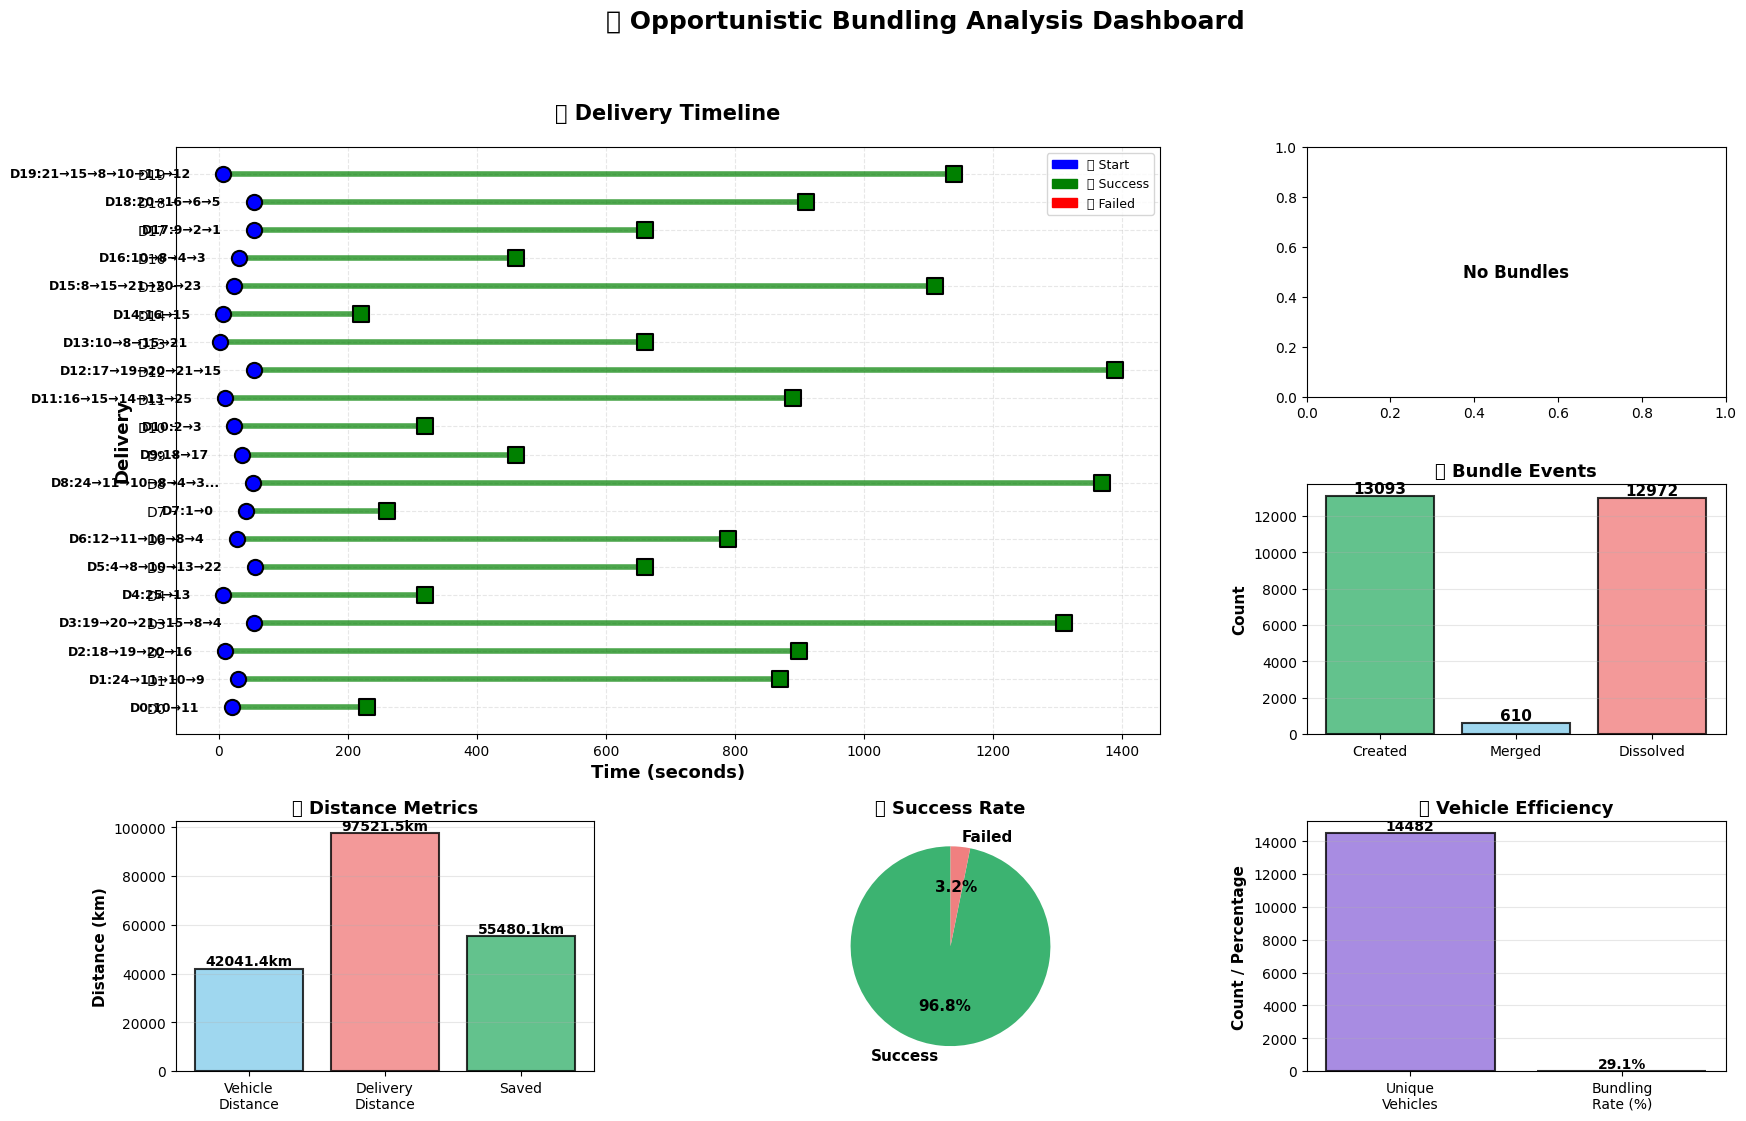

/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 128207 (\N{STRAIGHT RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-4184978521.py:272: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-418497852

✅ Comparison saved as 'bundling_comparison.png'


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128190 (\N{FLOPPY DISK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


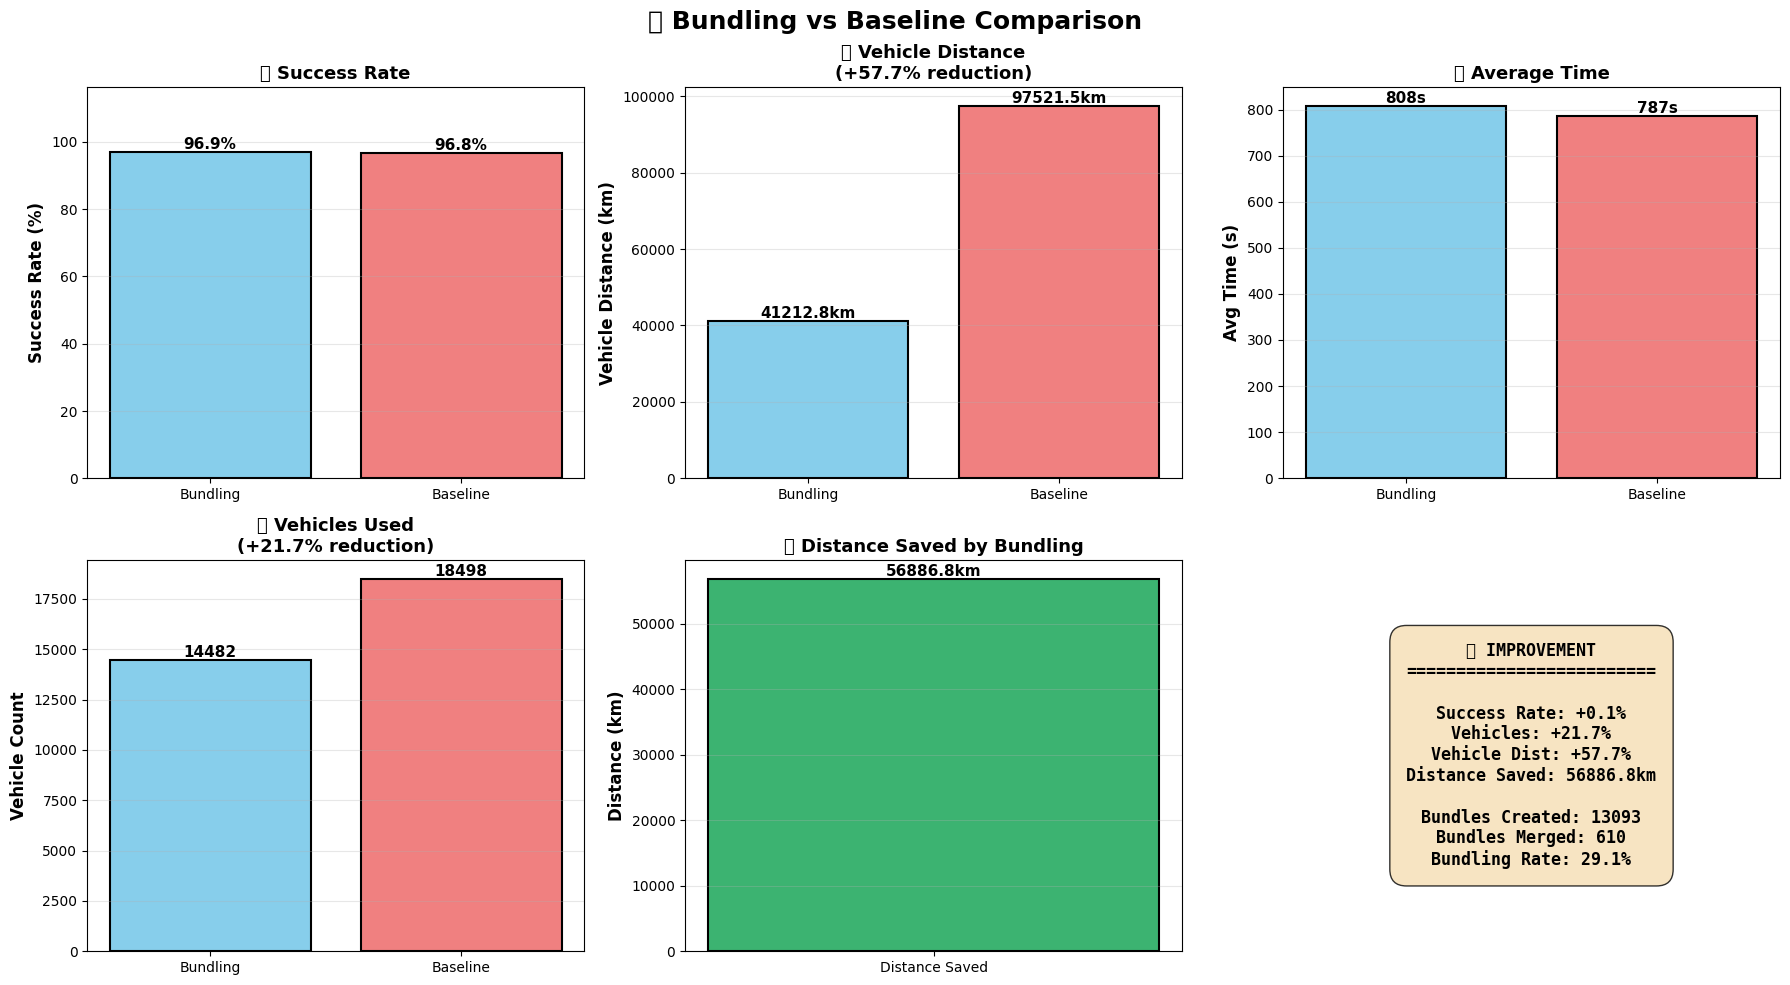

In [ ]:

# # ============================================================
# # 8. EXAMPLE USAGE
# # ============================================================

# Run comparison
bundling_results, baseline_results = compare_systems(
    deliverylist=deliverylist,
    adjacency_matrix=adjacency_matrix,
    node_positions=node_positions,
    num_hotspots=num_hotspots,
    grace_time=900,           # Extra time after all deliveries arrive
    wait_time=30,             # Max wait for bundle partners (seconds)
    max_bundle_size=5,        # Max deliveries per vehicle
    vehicle_change_time=15,   # Penalty per vehicle change (seconds)
    vehicle_cooldown=600      # Cooldown before vehicle reuse (seconds, 10 min)
)

# # # Or run individual simulations
# # bundling_results, bundling_sim = run_bundling_simulation(
# #     deliverylist=deliverylist,
# #     adjacency_matrix=adjacency_matrix,
# #     node_positions=node_positions,
# #     num_hotspots=num_hotspots,
# #     grace_time=900,
# #     wait_time=30,
# #     max_bundle_size=5,
# #     vehicle_change_time=15,
# #     vehicle_cooldown=10,
# #     debug=False
# # )

# # sim = Simulation(
# #     deliverylist=deliverylist,
# #     adjacency_matrix=adjacency_matrix,
# #     node_positions=node_positions,
# #     num_hotspots=num_hotspots,
# #     wait_time=30,
# #     max_bundle_size=5,
# #     vehicle_change_time=15,
# #     vehicle_cooldown=600,
# #     debug=False
# # )

# # sim.run(grace_time=600, use_bundling=False)
# # results = sim.get_results()



In [ ]:
error

NameError: name 'error' is not defined

## DeliverList Analysis

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import viridis
from matplotlib.colors import Normalize

# Extract delivery information
deliveries = deliverylist.deliveries

print(f"Total deliveries: {len(deliveries)}")
print(f"Number of hotspots (census tracts): {num_hotspots}")

# Create index mapping dictionaries
index_to_tract = {}
tract_to_index = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    index_to_tract[idx] = geoid
    tract_to_index[geoid] = idx

print(f"Created mapping for {len(index_to_tract)} census tracts")

# Extract delivery details
delivery_data = []
for i, delivery in enumerate(deliveries):
    data = {
        'delivery_id': i,
        'start_node': getattr(delivery, 'start_node', None),
        'end_node': getattr(delivery, 'end_node', None),
        'start_time': getattr(delivery, 'start_time', None),  # This is in seconds
        'num_shared': getattr(delivery, 'num_shared', 0) if hasattr(delivery, 'num_shared') else (len(delivery.shared) if hasattr(delivery, 'shared') and delivery.shared else 0)
    }
    delivery_data.append(data)

# Get hotspot locations using index mapping
index_to_location = {}
geoid_to_location = {}

for idx, row in census_gdf.iterrows():
    geoid = row['GEOID']
    centroid = row.geometry.centroid
    location = (centroid.x, centroid.y)

    index_to_location[idx] = location
    geoid_to_location[geoid] = location

print(f"Location mappings created: {len(index_to_location)}")

# Determine which mapping to use
def get_location(node):
    """Get location for a node, handling both index and GEOID formats"""
    if node is None:
        return None

    # Try as string (GEOID)
    node_str = str(node)
    if node_str in geoid_to_location:
        return geoid_to_location[node_str]

    # Try as integer index
    try:
        node_int = int(float(node_str))
        if node_int in index_to_location:
            return index_to_location[node_int]
        # Try mapping index to GEOID first
        if node_int in index_to_tract:
            geoid = index_to_tract[node_int]
            if geoid in geoid_to_location:
                return geoid_to_location[geoid]
    except:
        pass

    return None

# Select sample deliveries to show
num_samples = min(50, len(delivery_data))
sample_deliveries = delivery_data[:num_samples]

# === PREPARE TIME-BASED DATA (IN SECONDS) ===
# Start times are already in seconds
start_times_seconds = [d['start_time'] for d in delivery_data if d['start_time'] is not None]
start_times_minutes = [t / 60.0 for t in start_times_seconds]  # Convert seconds to minutes for display

# Simulation duration
simulation_duration_seconds = deliverylist.hours * 3600  # hours to seconds
simulation_duration_minutes = deliverylist.hours * 60  # hours to minutes

# Create bins for each minute (0-60 minutes = 0-3600 seconds)
num_minutes = int(simulation_duration_minutes)
minute_bins_seconds = np.arange(0, simulation_duration_seconds + 60, 60)  # Bins in seconds (0, 60, 120, ..., 3600)
delivery_counts, bin_edges = np.histogram(start_times_seconds, bins=minute_bins_seconds)

print(f"\nTime Analysis:")
print(f"  Simulation duration: {deliverylist.hours} hour(s) = {simulation_duration_minutes} minutes = {simulation_duration_seconds} seconds")
print(f"  Deliveries with time data: {len(start_times_seconds)}")
if start_times_seconds:
    print(f"  Time range: {min(start_times_seconds):.2f} - {max(start_times_seconds):.2f} seconds")
    print(f"              ({min(start_times_seconds)/60:.2f} - {max(start_times_seconds)/60:.2f} minutes)")

# Create visualization with 3 plots
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1.5])

fig.suptitle(f'Delivery Analysis (Load: {deliverylist.load}, Total: {len(deliveries)} deliveries, Duration: {num_minutes} minutes)',
             fontsize=16, fontweight='bold')

# === PLOT 1: Deliveries with Start/End Nodes Highlighted ===
ax1 = fig.add_subplot(gs[0, 0])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax1, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax1, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Plot all hotspot centroids (faded)
for idx, loc in index_to_location.items():
    ax1.scatter(loc[0], loc[1], s=30, c='lightgray', marker='o',
               edgecolors='gray', linewidths=0.5, alpha=0.3, zorder=2)

# Get start times for coloring (in seconds)
start_times_sample = [d['start_time'] for d in sample_deliveries if d['start_time'] is not None]

if start_times_sample:
    norm = Normalize(vmin=min(start_times_sample), vmax=max(start_times_sample))
    cmap = viridis

    # Plot each delivery route with colored line
    routes_plotted = 0
    for data in sample_deliveries:
        if data['start_node'] is not None and data['end_node'] is not None and data['start_time'] is not None:
            start_loc = get_location(data['start_node'])
            end_loc = get_location(data['end_node'])

            if start_loc and end_loc:
                color = cmap(norm(data['start_time']))

                # Draw route line
                ax1.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                        color=color, alpha=0.7, linewidth=2.5, zorder=4)

                # Mark start node (circle)
                ax1.scatter(start_loc[0], start_loc[1], s=180, c=[color],
                           marker='o', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                # Mark end node (square)
                ax1.scatter(end_loc[0], end_loc[1], s=180, c=[color],
                           marker='s', edgecolors='black', linewidths=2.5,
                           alpha=0.9, zorder=5)

                routes_plotted += 1

    print(f"Routes plotted in sample: {routes_plotted}")

    # Add colorbar (show in minutes for readability)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar1 = plt.colorbar(sm, ax=ax1, label='Start Time (seconds)', fraction=0.046, pad=0.04)

# Add legend for markers
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='Start Node'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='blue',
           markeredgecolor='black', markersize=10, label='End Node'),
    Line2D([0], [0], color='purple', linewidth=2, label='Delivery Route')
]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.set_title(f'Sample Delivery Routes (First {num_samples}) with Start (○) and End (□) Nodes', fontsize=13)
ax1.set_aspect('equal', adjustable='box')

# === PLOT 2: All Deliveries Overview with Density ===
ax2 = fig.add_subplot(gs[0, 1])

# Plot census tracts
if census_gdf is not None:
    census_gdf.boundary.plot(ax=ax2, color='gray', linewidth=0.8, alpha=0.6)
    census_gdf.plot(ax=ax2, color='lightgray', alpha=0.15, edgecolor='gray', linewidth=0.5)

# Count deliveries per hotspot for all deliveries
hotspot_activity = {}
for data in delivery_data:
    if data['start_node'] is not None:
        hotspot_activity[data['start_node']] = hotspot_activity.get(data['start_node'], 0) + 1
    if data['end_node'] is not None:
        hotspot_activity[data['end_node']] = hotspot_activity.get(data['end_node'], 0) + 1

# Plot hotspots sized and colored by activity
activities = []
locs_x = []
locs_y = []

for node, count in hotspot_activity.items():
    loc = get_location(node)
    if loc:
        activities.append(count)
        locs_x.append(loc[0])
        locs_y.append(loc[1])

if activities:
    # Plot with size proportional to activity
    sizes = [50 + a * 15 for a in activities]
    scatter = ax2.scatter(locs_x, locs_y, s=sizes, c=activities,
                         cmap='YlOrRd', edgecolors='black', linewidths=1,
                         alpha=0.7, zorder=5)

    # Add colorbar
    cbar2 = plt.colorbar(scatter, ax=ax2, label='Number of Deliveries',
                        fraction=0.046, pad=0.04)

# Plot all delivery routes (faded)
routes_total = 0
for data in delivery_data:
    if data['start_node'] is not None and data['end_node'] is not None:
        start_loc = get_location(data['start_node'])
        end_loc = get_location(data['end_node'])
        if start_loc and end_loc:
            ax2.plot([start_loc[0], end_loc[0]], [start_loc[1], end_loc[1]],
                    'b-', alpha=0.05, linewidth=0.5, zorder=2)
            routes_total += 1

print(f"Total routes plotted: {routes_total}")

ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.set_title(f'All {len(deliveries)} Deliveries - Hotspot Activity', fontsize=13)
ax2.set_aspect('equal', adjustable='box')

# === PLOT 3: Bar Chart - Deliveries per Minute ===
ax3 = fig.add_subplot(gs[1, :])

# Create bar chart (x-axis in minutes, but data binned from seconds)
minutes = np.arange(0, num_minutes)
bars = ax3.bar(minutes, delivery_counts, color='steelblue', edgecolor='black',
               linewidth=0.5, alpha=0.8)

# Highlight peak periods (peaks are in hours, convert to minutes)
# peaks=[0.25, 0.75] means 0.25*60=15 min and 0.75*60=45 min
peak_minutes = [p * 60 for p in deliverylist.peaks]
for peak_min in peak_minutes:
    if 0 <= peak_min < num_minutes:
        ax3.axvline(peak_min, color='red', linestyle='--', linewidth=2,
                   alpha=0.7, label=f'Peak at {peak_min:.0f} min' if peak_min == peak_minutes[0] else '')

# Add statistics
if len(delivery_counts) > 0:
    max_count = max(delivery_counts)
    max_minute = minutes[np.argmax(delivery_counts)]
    avg_count = np.mean(delivery_counts)

    ax3.axhline(avg_count, color='green', linestyle=':', linewidth=2,
               alpha=0.7, label=f'Average: {avg_count:.1f} deliveries/min')

    # Annotations
    ax3.text(max_minute, max_count, f'Max: {int(max_count)}\n@{int(max_minute)}min',
            ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax3.set_xlabel('Time (minutes)', fontsize=12)
ax3.set_ylabel('Number of Deliveries Starting', fontsize=12)
ax3.set_title(f'Delivery Distribution Over {num_minutes}-Minute Simulation', fontsize=13, fontweight='bold')
ax3.set_xlim(-1, num_minutes)
ax3.set_xticks(np.arange(0, num_minutes + 1, 5))
ax3.grid(True, alpha=0.3, axis='y')
ax3.legend(loc='upper right', fontsize=10)

# === PLOT 4: Statistics Summary ===
ax4 = fig.add_subplot(gs[2, :])

# Calculate time-based statistics
if start_times_seconds and len(delivery_counts) > 0:
    time_stats = f"""
TEMPORAL DISTRIBUTION STATISTICS
{'='*80}

Total Deliveries: {len(deliveries)}
Deliveries with Time Data: {len(start_times_seconds)}

TIME DISTRIBUTION:
  Simulation Duration: {simulation_duration_minutes:.0f} minutes ({simulation_duration_seconds:.0f} seconds)
  Peak Times (configured): {', '.join([f'{p*60:.0f} min ({p*3600:.0f}s)' for p in deliverylist.peaks])}
  Actual Peak Time: Minute {int(max_minute)} with {int(max_count)} deliveries

  Min deliveries/minute: {int(min(delivery_counts))}
  Max deliveries/minute: {int(max_count)}
  Average deliveries/minute: {avg_count:.2f}
  Standard deviation: {np.std(delivery_counts):.2f}

DISTRIBUTION CHARACTERISTICS:
  First delivery at: {min(start_times_seconds):.2f} seconds ({min(start_times_seconds)/60:.2f} minutes)
  Last delivery at: {max(start_times_seconds):.2f} seconds ({max(start_times_seconds)/60:.2f} minutes)
  Median delivery time: {np.median(start_times_seconds):.2f} seconds ({np.median(start_times_seconds)/60:.2f} minutes)

LOAD PARAMETER EXPLANATION:
  Load = {deliverylist.load} acts as a scaling factor
  This generated {len(deliveries)} deliveries ({len(deliveries) / deliverylist.load:.1f} per load unit)
  Distributed across {num_hotspots} available hotspots
  Using {len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))} unique hotspots ({len(set([d['start_node'] for d in delivery_data if d['start_node']] + [d['end_node'] for d in delivery_data if d['end_node']]))/num_hotspots*100:.1f}% utilization)
"""
else:
    time_stats = "No time data available"

ax4.text(0.05, 0.5, time_stats, fontsize=10, family='monospace',
        verticalalignment='center', transform=ax4.transAxes)
ax4.axis('off')

plt.tight_layout()
plt.show()

# Print minute-by-minute breakdown for first 20 minutes
print("\n" + "="*60)
print("DELIVERIES PER MINUTE (First 20 minutes):")
print("="*60)
print(f"{'Minute':<10} {'Time Range (s)':<20} {'Count':<10} {'Bar':<30}")
print("-"*60)
for i in range(min(20, len(delivery_counts))):
    time_range = f"{i*60}-{(i+1)*60}"
    bar = '█' * int(delivery_counts[i])
    print(f"{i:<10} {time_range:<20} {int(delivery_counts[i]):<10} {bar}")

print(f"\n... Total across all {num_minutes} minutes: {int(sum(delivery_counts))} deliveries")

# Print sample deliveries with time in seconds
print("\n" + "="*100)
print(f"SAMPLE DELIVERIES (First 10):")
print("="*100)
print(f"{'ID':<5} {'Start Node':<12} {'End Node':<12} {'Start Time (s)':<15} {'Start Time (min)':<15} {'Shared':<8}")
print("-"*100)

for i, data in enumerate(delivery_data[:10]):
    start_node = str(data['start_node']) if data['start_node'] is not None else "N/A"
    end_node = str(data['end_node']) if data['end_node'] is not None else "N/A"
    start_time_s = f"{data['start_time']:.2f}" if data['start_time'] is not None else "N/A"
    start_time_m = f"{data['start_time']/60:.2f}" if data['start_time'] is not None else "N/A"

    print(f"{i+1:<5} {start_node:<12} {end_node:<12} {start_time_s:<15} {start_time_m:<15} {data['num_shared']:<8}")